In [1]:
import polars as pl


# df = pd.read_csv("../../data/hawkdovemulti/2025-07-22T170057_747737_agent.csv")
# df = pd.read_csv("../../data/hawkdovemulti/2025-07-23T135510_859267_agent.csv")
# which batch run data to use; use variable to ensure we use matching agent and model data
batch_run_date = "2025-07-24T120337_924060"
# batch_run_date = "2026-06-02T150400_876920"

# data/hawkdovemulti/2026-06-02T150400_876920_model.csv

# load agent data, drop unneeded columns, and add numeric value 1 for played hawk, 0 for played dove
df = (
    pl.read_csv(f"../../data/hawkdovemulti/{batch_run_date}_agent.csv")
        .drop("risk_level_changed")  # drop risk_level_changed; not relevant here (no adjustment = no changes)
        .rename({'risk_level': 'risk_attitude'})  # code still uses risk_level internally; relabel as risk attitude
        .with_columns(
            # add a numeric field to turn choice of play to 1/0 hawk, for aggregation            
            played_hawk=pl.when(pl.col("choice").eq("hawk")).then(1).otherwise(0)
        )
)
df.head()

RunId,iteration,Step,AgentID,risk_attitude,choice,points,played_hawk
i64,i64,i64,i64,i64,str,i64,i32
1,1,1,0,3,"""dove""",12,0
1,1,1,1,8,"""dove""",12,0
1,1,1,2,8,"""hawk""",12,1
1,1,1,3,4,"""hawk""",18,1
1,1,1,4,8,"""hawk""",15,1


In [20]:
# identify the last round of each run
# for both wealth analysis and model parameters, we want to look at the last round (Step) of each run
last_round_df = df.group_by("RunId").agg(pl.col("Step").max())

# load model data and filter to last round for each run
full_model_df = pl.read_csv(f"../../data/hawkdovemulti/{batch_run_date}_model.csv")
model_df = last_round_df.join(full_model_df, on=['RunId', 'Step'], how="left")
# limit to only those fields that are needed for our analysis
model_df = model_df.select("RunId", "iteration", "risk_distribution", "play_neighborhood", "observed_neighborhood", "grid_size", "Step")
model_df = model_df.filter(pl.col.grid_size.is_not_null())
model_df

RunId,iteration,risk_distribution,play_neighborhood,observed_neighborhood,grid_size,Step
i64,i64,str,i64,i64,i64,i64
8277,77,"""skewed right""",8,8,10,64
3689,89,"""normal""",24,8,5,59
149,49,"""uniform""",8,8,10,62
8402,2,"""skewed right""",8,24,5,31
265,65,"""uniform""",8,8,25,31
…,…,…,…,…,…,…
7059,59,"""skewed left""",24,4,10,64
8646,46,"""skewed right""",8,24,25,31
9822,22,"""skewed right""",24,4,25,49


In [3]:
# get the number of simulation runs; this is from a single run, so we can just count unique simulation run id
num_simulation_runs = df["RunId"].n_unique()
print(f"{num_simulation_runs:,} total simulation runs")

13,500 total simulation runs


In [4]:
# combine the last round dataframe and full agent dataframe to get just the last round of each run
agents_last_round_df = (
    last_round_df.join(df, on=['RunId', 'Step'], how="left")
        # join on model parameters, for filtering and scaling by play neighborhood
        .join(model_df, on=["RunId", "iteration"])
        .with_columns(
            # calculate a scaled points value so we can compare across runs with different length and play neighborhood
            scaled_points=pl.col("points").truediv(pl.col("play_neighborhood")).truediv(pl.col("Step")).mul(100)
        )
    
)
agents_last_round_df.height

3375000

In [21]:
agents_last_round_df.head()

RunId,Step,iteration,AgentID,risk_attitude,choice,points,played_hawk,risk_distribution,play_neighborhood,observed_neighborhood,grid_size,Step_right,scaled_points
i64,i64,i64,i64,i64,str,i64,i32,str,i64,i64,i64,i64,f64
8131,31,31,0,9,"""dove""",432,0,"""skewed right""",8,8,5,31,174.193548
8131,31,31,1,9,"""dove""",418,0,"""skewed right""",8,8,5,31,168.548387
8131,31,31,2,8,"""dove""",433,0,"""skewed right""",8,8,5,31,174.596774
8131,31,31,3,7,"""dove""",403,0,"""skewed right""",8,8,5,31,162.5
8131,31,31,4,5,"""hawk""",645,1,"""skewed right""",8,8,5,31,260.080645


Here is the payoff distribution chart in question. How significant is the slight dip for the risk-neutral agents in the middle? How confident are we in these numbers?

In [19]:
import altair as alt

alt.data_transformers.enable("vegafusion")

payoffchart_title = alt.TitleParams(
    "Cumulative Payoff Distribution by Risk Attitude",
    subtitle=f"Payoff scaled by simulation length and play neighborhood across {num_simulation_runs:,} simulations"
)

cum_payoff_boxplot = alt.Chart(agents_last_round_df, title=payoffchart_title).mark_boxplot(extent="min-max").encode(
    x=alt.X("risk_attitude", title="Risk Attitude").scale(domain=[0, 9]),
    y=alt.X("scaled_points", title="Cumulative Payoff"),
) 
cum_payoff_boxplot

alt.Chart(...)

In [47]:
cum_payoff_boxplot.facet("risk_distribution", columns=3, title="Cumulative Payoff Distribution by Risk Attitude and initial risk distribution")

alt.FacetChart(...)

In [48]:
cum_payoff_boxplot.facet("play_neighborhood", title="Cumulative Payoff Distribution by Risk Attitude and Play Neighborhood Size")

alt.FacetChart(...)

In [49]:
cum_payoff_boxplot.facet("observed_neighborhood", title="Cumulative Payoff Distribution by Risk Attitude and Play Neighborhood Size")

alt.FacetChart(...)

In [50]:
cum_payoff_boxplot.facet("grid_size", title="Cumulative Payoff Distribution by Risk Attitude and Grid Size")

alt.FacetChart(...)

In [7]:
# altair can do confidence intervals based on boostrap sampling - but the scale of our data doesn't work in a notebook 
# (causes an error that prevents the notebook from being saved)

# payoff_ci = alt.Chart(agents_last_round_df).mark_errorbar().encode(
#     x=alt.X("risk_attitude", title="Risk Attitude").scale(domain=[0, 9]),
#     y=alt.X("scaled_points", title="Cumulative Payoff").scale(zero=False),
# ) 
# payoff_ci

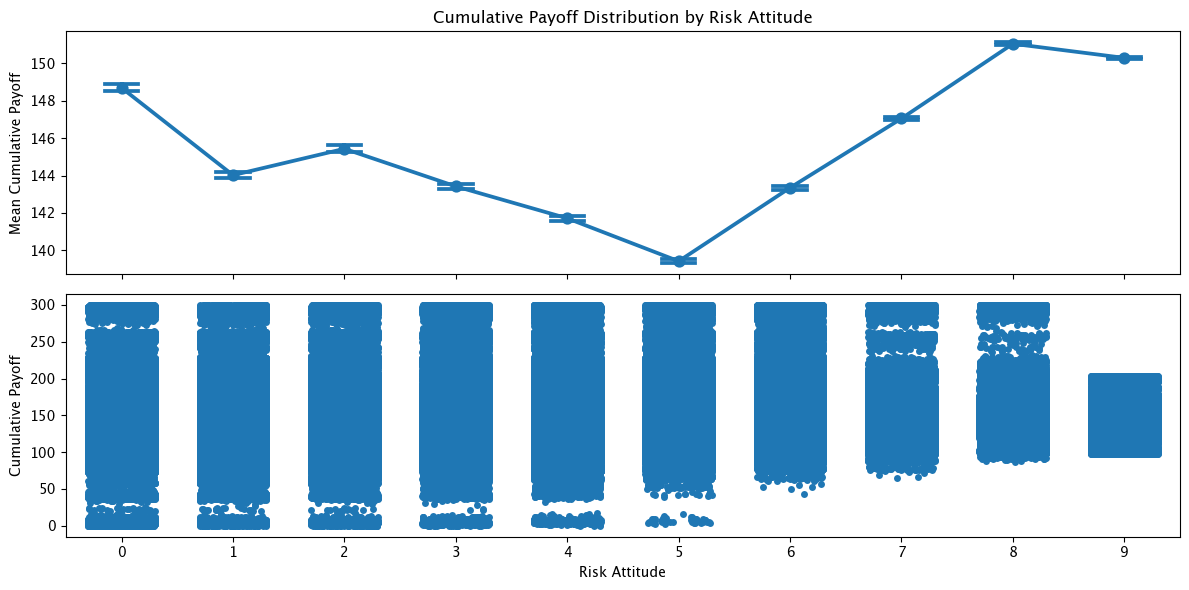

In [55]:
import importlib
import seaborn as sns
importlib.reload(sns)
import matplotlib.pyplot as plt

f, axs = plt.subplots(2, figsize=(12, 6), sharex=True, layout="tight")
fig1 = sns.pointplot(y=agents_last_round_df['scaled_points'], x=agents_last_round_df["risk_attitude"], errorbar="ci", capsize=.3, ax=axs[0])
fig1.set_ylabel("Mean Cumulative Payoff")
fig1.set_title("Cumulative Payoff Distribution by Risk Attitude")
fig2 = sns.stripplot(y=agents_last_round_df['scaled_points'], x=agents_last_round_df["risk_attitude"], jitter=.3, ax=axs[1])
fig2.set_xlabel("Risk Attitude")
fig2.set_ylabel("Cumulative Payoff")

ci_jitter_meanplot =  f.get_figure()
# ci_jitter_meanplot.set_title("Cumulative Payoff Distribution by Risk Attitude")
# ci_jitter_meanplot.text(x=0.5, y=1.025, s="With 95% confidence intervals based on mean", horizontalalignment='center')

#ci_jitter_meanplot.savefig("ci_jitter_mean_cumulative_payoff.png")

Text(0, 0.5, 'Cumulative Payoff')

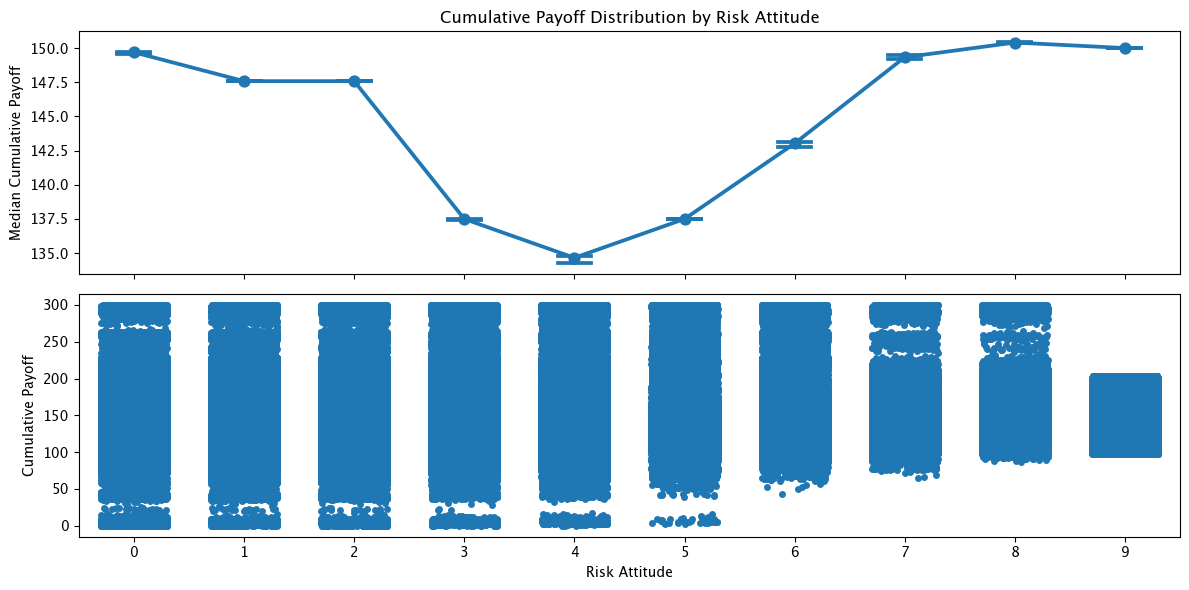

In [9]:
# standard error formula is specific to the mean, error bars can be computed using the bootstrap for any estimator; let's try the median

f2, axs2 = plt.subplots(2, figsize=(12, 6), sharex=True, layout="tight")
fig2a = sns.pointplot(y=agents_last_round_df['scaled_points'], x=agents_last_round_df["risk_attitude"], errorbar="ci", capsize=.3, ax=axs2[0], estimator="median")
fig2a.set_ylabel("Median Cumulative Payoff")
fig2a.set_title("Cumulative Payoff Distribution by Risk Attitude")
fig2b = sns.stripplot(y=agents_last_round_df['scaled_points'], x=agents_last_round_df["risk_attitude"], jitter=.3, ax=axs2[1])
fig2b.set_xlabel("Risk Attitude")
fig2b.set_ylabel("Cumulative Payoff")

# f2.get_figure().savefig("ci_jitter_median_cumulative_payoff.png")

Text(0.5, 1.0, 'Cumulative Payoff Distribution by Risk Attitude')

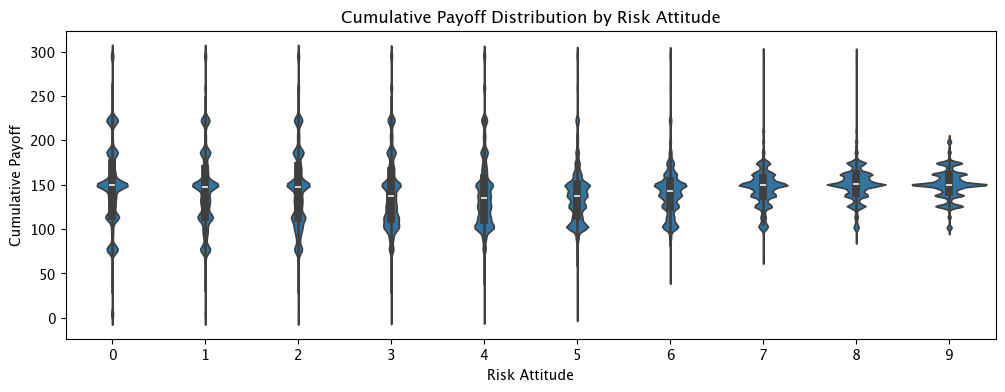

In [10]:

fig_v, ax_v = plt.subplots(figsize=(12, 4))
vplot = sns.violinplot(ax=ax_v, data=agents_last_round_df, x="risk_attitude", y="scaled_points")

vplot.set_xlabel("Risk Attitude")
vplot.set_ylabel("Cumulative Payoff")
vplot.set_title( "Cumulative Payoff Distribution by Risk Attitude")

# save to file
# vplot_fig = vplot.get_figure()
# vplot_fig.savefig("cumulative_payoff_violinplot.png")

/Users/rkoeser/workarea/env/simrisk/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the violinplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


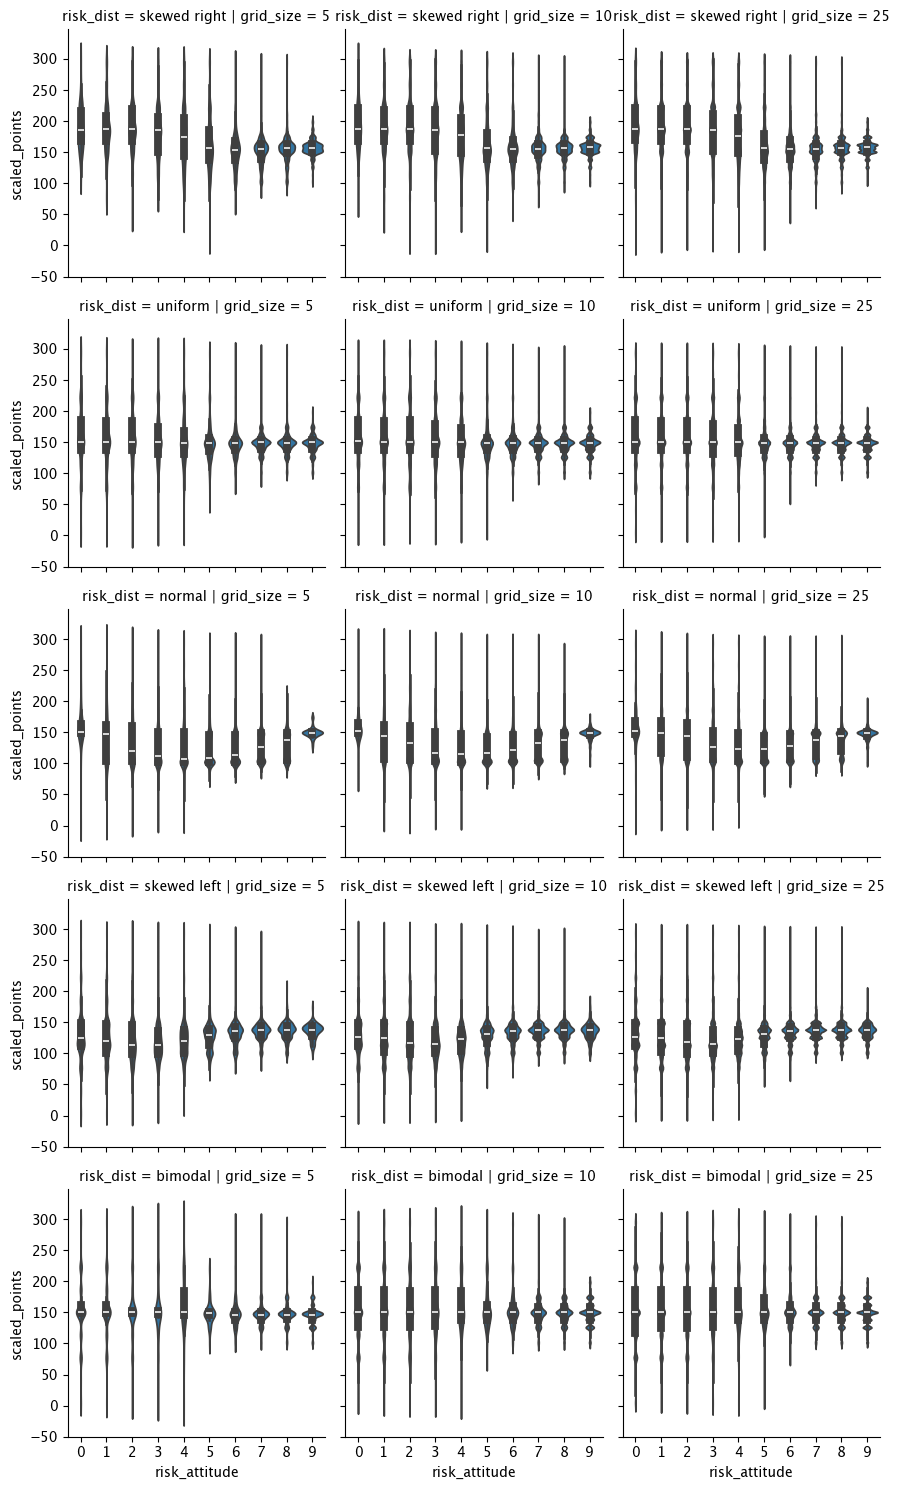

In [68]:
g = sns.FacetGrid(agents_last_round_df.rename({"risk_distribution": "risk_dist"}), col="grid_size",  row="risk_dist")
g.map(sns.violinplot, "risk_attitude", "scaled_points")
g.savefig("cum_payoff_risk_dist.png")

/Users/rkoeser/workarea/env/simrisk/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the violinplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


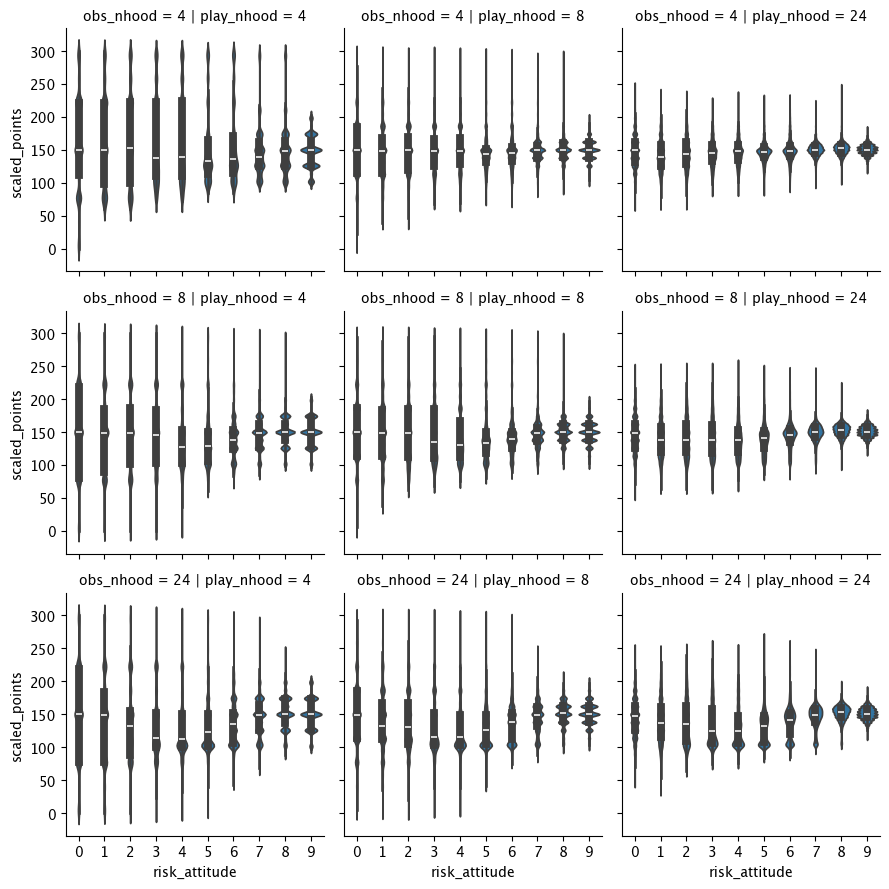

In [69]:
g = sns.FacetGrid(agents_last_round_df.rename({"play_neighborhood": "play_nhood", "observed_neighborhood": "obs_nhood"}), col="play_nhood",  row="obs_nhood")
g.map(sns.violinplot, "risk_attitude", "scaled_points")
g.savefig("cum_payoff_nhood.png")

## manual bootstrap sampling 

As a comparison to the Seaborn plots, test implementing bootstrap sampling in polars - gather mean, median, and Q2/Q3.


In [5]:
payoff_stats_df = agents_last_round_df.group_by("risk_attitude").agg(
            mean=pl.col.scaled_points.mean(), 
            median=pl.col.scaled_points.median(), 
            q1=pl.col.scaled_points.quantile(0.25),
            # q2=pl.col.scaled_points.quantile(0.5),
            q3=pl.col.scaled_points.quantile(0.75))

payoff_stats_df

risk_attitude,mean,median,q1,q3
i64,f64,f64,f64,f64
6,143.347455,143.025362,125.403226,154.301075
9,150.287365,150.0,141.397849,160.887097
3,143.420712,137.5,110.849057,165.957447
0,148.685253,149.691358,114.919355,174.596774
1,144.020105,147.580645,113.206215,167.79661
4,141.715225,134.659091,109.946237,157.258065
7,147.048369,149.327957,137.037037,158.064516
8,151.041036,150.403226,140.254237,161.693548
2,145.429545,147.580645,112.5,170.564516


In [30]:
# running here was too slow (perhaps because the 0.5 fraction is still so large); load pre-callculated set

# def bootstrap_payoff_stats_OLD(df, fraction, repeat):
#     # initial naive approach - loop manually
#     # ignore fraction and resample all
#     # subset_df = df.sample(fraction=fraction, shuffle=True)
#     stats_df = None
#     for i in range(repeat):
#         resample = df.sample(fraction=1, with_replacement=True)
#         resample_stats = resample.group_by("risk_attitude").agg(
#             mean=pl.col.scaled_points.mean(), 
#             median=pl.col.scaled_points.median(), 
#             q1=pl.col.scaled_points.quantile(0.25),
#             q2=pl.col.scaled_points.quantile(0.5),
#             q3=pl.col.scaled_points.quantile(0.75))
#         if stats_df is None:
#             stats_df = resample_stats
#         else:
#             stats_df = stats_df.vstack(resample_stats)

#     return stats_df


# # use polars collect all to parallelize the bootstrap sampling & aggregation
# # adapted from https://stackoverflow.com/a/76359078
# def bootstrap_payoff_stats(df, fraction, repeat):
#     collected_stats_df = pl.concat(pl.collect_all(
#        [
#           agents_last_round_df.sample(fraction=fraction, with_replacement=True).lazy().group_by("risk_attitude").agg(
#             mean=pl.col.scaled_points.mean(), 
#             median=pl.col.scaled_points.median(), 
#             q1=pl.col.scaled_points.quantile(0.25),
#             q2=pl.col.scaled_points.quantile(0.5),
#             q3=pl.col.scaled_points.quantile(0.75))
#           for _ in range(repeat)
#        ]
#     ))
#     collected_stats_df
    


# resampled_stats_df = bootstrap_payoff_stats(agents_last_round_df, 0.5, 5000)
# resampled_stats_df = bootstrap_payoff_stats(agents_last_round_df, 0.5, 10)

# collected_stats = pl.collect_all(
#    [
#       agents_last_round_df.sample(fraction=0.5, with_replacement=True).lazy().group_by("risk_attitude").agg(
#         mean=pl.col.scaled_points.mean(), 
#         median=pl.col.scaled_points.median(), 
#         q1=pl.col.scaled_points.quantile(0.25),
#         # q2=pl.col.scaled_points.quantile(0.5),
#         q3=pl.col.scaled_points.quantile(0.75))
#       for _ in range(5000)
#    ]
# )

# lazy_stats_df = pl.read_csv("../../data/hawkdovemulti/payoff_bootstrap_stats.csv")

lazy_stats_df = pl.read_csv("../../data/hawkdovemulti/payoff_bootstrap_stats_2pct_10k.csv")

In [ ]:
# lazy_stats_df = pl.concat(collected_stats)
# lazy_stats_df = pl.concat(

In [31]:
lazy_stats_df.height

100000

In [32]:

r4_bins = alt.Chart(lazy_stats_df.filter(pl.col.risk_attitude.eq(4))).mark_bar().encode(
    alt.X("mean:Q", bin=True),
    y='count()',
)

r4_bins

alt.Chart(...)

In [33]:

mean_binned_chart = alt.Chart(lazy_stats_df).mark_bar().encode(
    alt.X("mean", bin=True),
    y='count()',
)
mean_binned_chart.facet("risk_attitude", columns=5)

alt.FacetChart(...)

In [40]:
# calculate 95% confidence interval for each risk attitude

sample_ci_bounds = lazy_stats_df.group_by("risk_attitude").agg(
    # 95% confidence interval for mean
    mean_ci_lower=pl.col.mean.quantile(0.025),
    mean_ci_upper=pl.col.mean.quantile(0.975),
    # 95% confidence interval for median
    median_ci_lower=pl.col.median.quantile(0.025),
    median_ci_upper=pl.col.median.quantile(0.975),
    # q1 confidence interval
    q1_ci_lower=pl.col.q1.quantile(0.025),
    q1_ci_upper=pl.col.q1.quantile(0.975),
    # q3 confidence interval
    q3_ci_lower=pl.col.q3.quantile(0.025),
    q3_ci_upper=pl.col.q3.quantile(0.975),
    
)

sample_ci_bounds.sort("risk_attitude")

risk_attitude,mean_ci_lower,mean_ci_upper,median_ci_lower,median_ci_upper,q1_ci_lower,q1_ci_upper,q3_ci_lower,q3_ci_upper
i64,f64,f64,f64,f64,f64,f64,f64,f64
0,148.449578,148.91521,149.596774,149.731183,114.919355,114.919355,174.489796,174.731183
1,143.777626,144.264644,147.457627,147.580645,113.135593,113.276836,167.584746,168.145161
2,145.191439,145.670208,147.457627,147.580645,112.5,112.5,169.70339,172.177419
3,143.210479,143.635642,137.339744,137.634409,110.507246,111.087571,164.919355,166.666667
4,141.528133,141.908331,134.274194,134.946237,109.677419,110.208333,156.790123,157.66129
5,139.264808,139.575521,137.5,137.5,114.112903,114.516129,150.806452,150.806452
6,143.202899,143.497599,142.741935,143.145161,125.396825,125.423729,154.166667,154.435484
7,146.932559,147.162857,149.193548,149.462366,136.864407,137.096774,158.012821,158.19209
8,150.938643,151.14649,150.403226,150.423729,139.919355,140.322581,161.652542,161.693548


In [41]:
# graph results for risk attitude 4 to check the logic
# based on https://inferentialthinking.com/chapters/13/2/bootstrap/

mean_r4_bin_chart = alt.Chart(lazy_stats_df.filter(pl.col.risk_attitude.eq(4))).mark_bar().encode(
    alt.X("mean:Q", bin=True),
    y='count()',
)
mean_r4_rule_chart = alt.Chart(sample_ci_bounds.filter(pl.col.risk_attitude.eq(4))).mark_rule(color="yellow", size=5).encode(
    x='mean_ci_lower', x2='mean_ci_upper', y=alt.value('height')
    # y='count()',
)

(mean_r4_bin_chart + mean_r4_rule_chart)

alt.LayerChart(...)

In [42]:
ci_bars = alt.Chart(sample_ci_bounds).mark_rule(color="gray", size=3, opacity=0.5).encode(
    y='mean_ci_lower', y2='mean_ci_upper',
    x='risk_attitude',
)

stats_base_chart = alt.Chart(payoff_stats_df)
mean_points = stats_base_chart.mark_point(size=40).encode(
    y=alt.Y('mean').scale(zero=False), x='risk_attitude')


mean_line = stats_base_chart.mark_line().encode(
    y=alt.Y('mean').scale(zero=False), x='risk_attitude')


ci_bars + mean_points + mean_line

alt.LayerChart(...)

In [43]:
# write a method to create the combined line + points chart with confidence interval

def chart_stat_ci(measure):
    # assumes sample_ci_bounds and payoff_stats_df are already set up

    # draw rulers for 95% confidence interval
    ci_bars = alt.Chart(sample_ci_bounds).mark_rule(color="black", size=3).encode(
        y=f'{measure}_ci_lower', y2=f'{measure}_ci_upper',
        x='risk_attitude',
    )
    stats_base_chart = alt.Chart(payoff_stats_df)
    points = stats_base_chart.mark_point(size=10).encode(
        y=alt.Y(measure, title=f"{measure.title()}").scale(zero=False), 
        x=alt.X('risk_attitude', title="Risk Attitude"))
    line = stats_base_chart.mark_line().encode(
        y=alt.Y(measure).scale(zero=False), x='risk_attitude')
    
    return (points + line + ci_bars)
    

In [44]:
(chart_stat_ci("mean") | chart_stat_ci("median") | chart_stat_ci("q1") | chart_stat_ci("q3")).properties(title="Statistics for cumulative payoff distribution with confidence intervals")

alt.HConcatChart(...)